In [1]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [5]:
tf.keras.datasets.mnist

<module 'keras.datasets.mnist' from '/usr/local/lib/python3.12/dist-packages/keras/datasets/mnist/__init__.py'>

In [2]:
import numpy as np

# Import Matplotlib
import matplotlib.pyplot as plt


In [6]:
from tensorflow.keras.datasets import mnist

In [7]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


In [17]:
print(y_train[10])

3


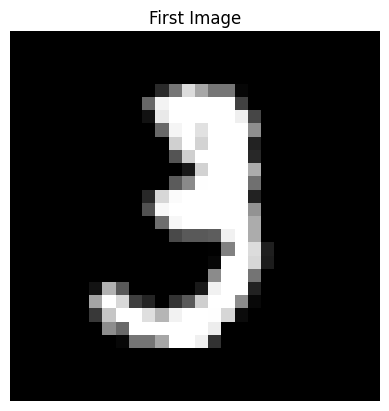

In [16]:
plt.imshow(X_train[10], cmap='gray')
plt.title("First Image")
plt.axis('off')
plt.show()

In [20]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [21]:
# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

In [22]:
print("Minimum value:", X_train.min())
print("Maximum value:", X_train.max())

Minimum value: 0.0
Maximum value: 1.0


In [23]:
print(X_train.shape)

(60000, 28, 28)


In [25]:
# Flatten images
X_train = X_train.reshape(X_train.shape[0], 784)
X_test = X_test.reshape(X_test.shape[0], 784)

In [26]:
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [27]:
from tensorflow.keras.utils import to_categorical

# Convert labels to one-hot vectors
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [28]:
print(y_train[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [37]:
model_relu = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_relu.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
activation='relu'

In [41]:
model_relu.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
history_relu = model_relu.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9941 - loss: 0.0173 - val_accuracy: 0.9761 - val_loss: 0.1117
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9948 - loss: 0.0151 - val_accuracy: 0.9763 - val_loss: 0.1165
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9948 - loss: 0.0152 - val_accuracy: 0.9760 - val_loss: 0.1239
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9959 - loss: 0.0120 - val_accuracy: 0.9737 - val_loss: 0.1435
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9950 - loss: 0.0131 - val_accuracy: 0.9720 - val_loss: 0.1506
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9962 - loss: 0.0119 - val_accuracy: 0.9769 - val_loss: 0.1283
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9967 - loss: 0.0092 - val_accuracy: 0.9753 - val_loss: 0.1416
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9964 - loss: 0.0111 - 

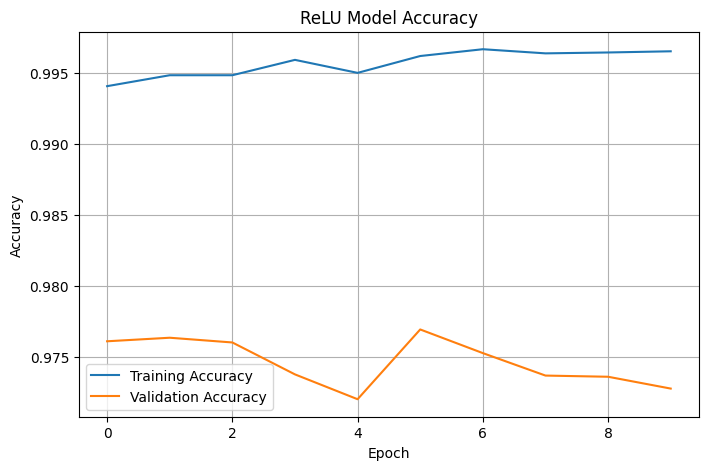

In [45]:
plt.figure(figsize=(8,5))

plt.plot(history_relu.history['accuracy'], label='Training Accuracy')
plt.plot(history_relu.history['val_accuracy'], label='Validation Accuracy')

plt.title('ReLU Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.grid(True)

plt.show()

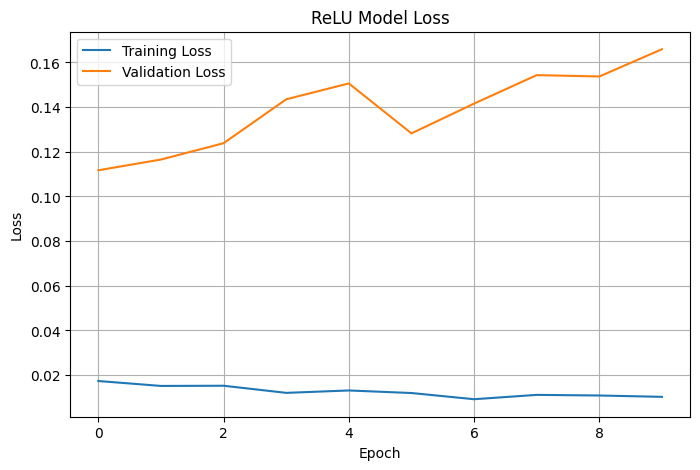

In [46]:
plt.figure(figsize=(8,5))

plt.plot(history_relu.history['loss'], label='Training Loss')
plt.plot(history_relu.history['val_loss'], label='Validation Loss')

plt.title('ReLU Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.grid(True)

plt.show()

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model_sigmoid = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='sigmoid'),
    Dense(64, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model_sigmoid.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model_sigmoid.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
history_sigmoid = model_sigmoid.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8680 - loss: 0.5318 - val_accuracy: 0.9278 - val_loss: 0.2456
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9403 - loss: 0.2052 - val_accuracy: 0.9494 - val_loss: 0.1746
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9570 - loss: 0.1463 - val_accuracy: 0.9605 - val_loss: 0.1331
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9678 - loss: 0.1101 - val_accuracy: 0.9666 - val_loss: 0.1157
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9750 - loss: 0.0865 - val_accuracy: 0.9666 - val_loss: 0.1104
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9794 - loss: 0.0688 - val_accuracy: 0.9676 - val_loss: 0.1028
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9838 - loss: 0.0550 - val_accuracy: 0.9731 - val_loss: 0.0893
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9875 - loss: 0.0445 - 

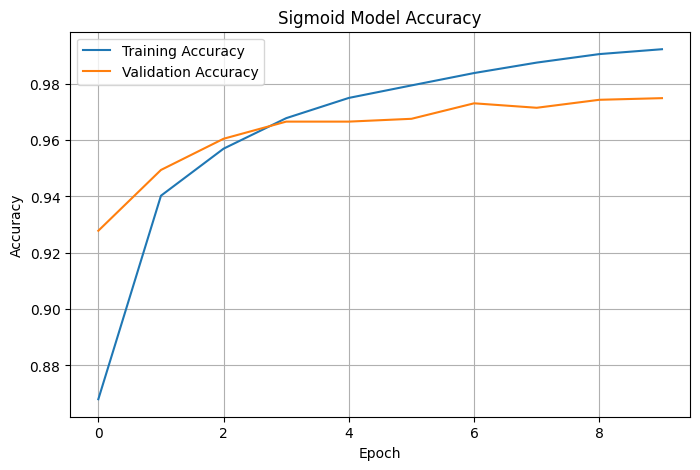

In [50]:
plt.figure(figsize=(8,5))

plt.plot(history_sigmoid.history['accuracy'], label='Training Accuracy')
plt.plot(history_sigmoid.history['val_accuracy'], label='Validation Accuracy')

plt.title('Sigmoid Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

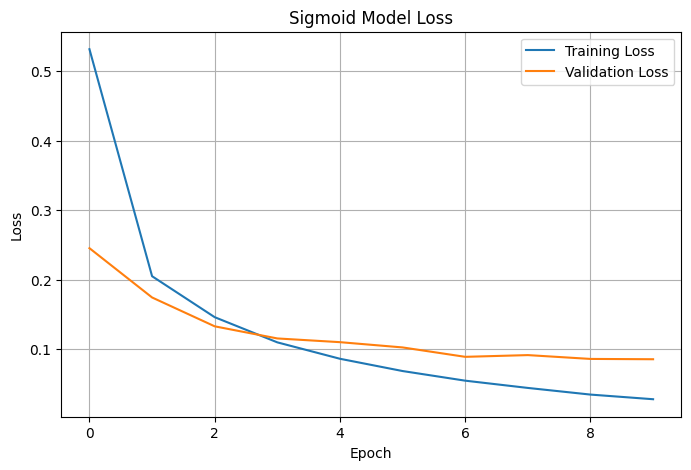

In [51]:
plt.figure(figsize=(8,5))

plt.plot(history_sigmoid.history['loss'], label='Training Loss')
plt.plot(history_sigmoid.history['val_loss'], label='Validation Loss')

plt.title('Sigmoid Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [52]:
relu_loss, relu_accuracy = model_relu.evaluate(X_test, y_test, verbose=0)

print("ReLU Test Accuracy :", relu_accuracy)
print("ReLU Test Loss :", relu_loss)

ReLU Test Accuracy : 0.9735000133514404
ReLU Test Loss : 0.15395958721637726


In [53]:
sigmoid_loss, sigmoid_accuracy = model_sigmoid.evaluate(X_test, y_test, verbose=0)

print("Sigmoid Test Accuracy :", sigmoid_accuracy)
print("Sigmoid Test Loss :", sigmoid_loss)

Sigmoid Test Accuracy : 0.9746000170707703
Sigmoid Test Loss : 0.0837819054722786


In [54]:
print("\nComparison of Models")
print("-"*40)

print(f"ReLU Accuracy    : {relu_accuracy:.4f}")
print(f"ReLU Loss        : {relu_loss:.4f}")

print()

print(f"Sigmoid Accuracy : {sigmoid_accuracy:.4f}")
print(f"Sigmoid Loss     : {sigmoid_loss:.4f}")


Comparison of Models
----------------------------------------
ReLU Accuracy    : 0.9735
ReLU Loss        : 0.1540

Sigmoid Accuracy : 0.9746
Sigmoid Loss     : 0.0838


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


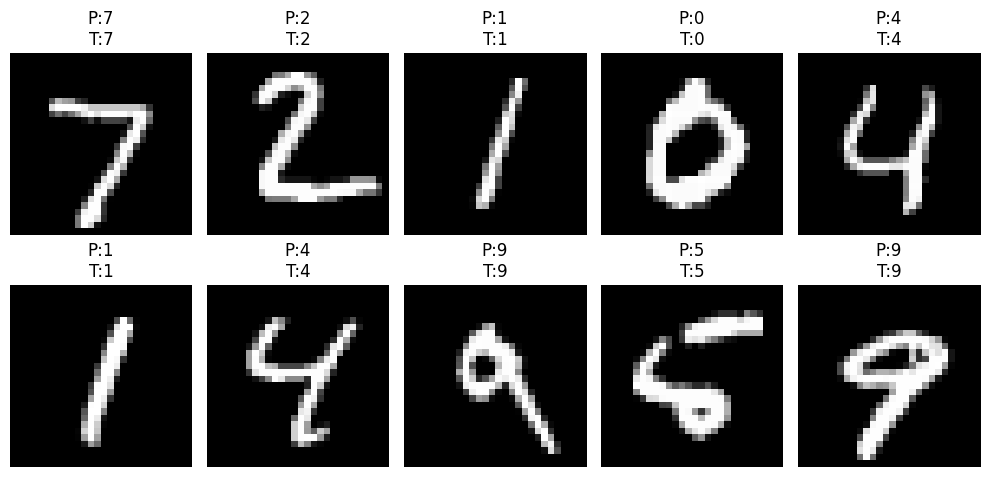

In [55]:
predictions = model_relu.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"P:{predicted_labels[i]}\nT:{true_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()